# Sydney House Price Analysis

# Part 3 – Model Development and Evaluation

- Compare three regression models using the collected property data.
- Use the same five folds for each model.
- Compare training and validation results.

## 1. Model choices before training

- **Linear Regression:** A simple baseline for the 102 properties. It is easy to interpret, but it may miss nonlinear price patterns.
- **Random Forest:** Can capture interactions between suburb and property features. Its depth is limited to reduce overfitting on this small dataset.
- **Gradient Boosting:** Builds trees in sequence to improve predictions. It may fit the small dataset too closely.
- **Initial expectation:** Random Forest is expected to perform best overall. The final choice will use validation RMSE, with MAE, R² and fold results checked as well.


## 2. Import Libraries


In [1]:
import warnings
# A rare category may be absent from a training fold. The encoder handles it.
warnings.filterwarnings("ignore", message="Found unknown categories.*", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

import sklearn
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.6.1


## 3. Load the Excel file

- Keep the Excel file in the same folder as this notebook.
- Change `FILE_PATH` if the filename is different.
- Read the `Sold Properties` sheet only.
- Accept either sale-price heading without changing the Excel file.


In [2]:
from pathlib import Path

FILE_PATH = "Sydney_Sold_Property_Dataset (1).xlsx"
SHEET_NAME = "Sold Properties"

# Keep the original Excel file unchanged.
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df.columns = df.columns.str.strip()
df = df.rename(columns={"Sold Price (AUD) - TARGET": "Sold Price (AUD)", "Sold Price (AUD) - Target": "Sold Price (AUD)"})
assert df.columns.is_unique, "Check for repeated column headings."
assert "Sold Price (AUD)" in df.columns, "The sold-price column is missing."
assert df["Sold Price (AUD)"].notna().all(), "Some properties have no sold price."
assert pd.api.types.is_numeric_dtype(df["Sold Price (AUD)"]), "Sold prices must be numeric."
print("Dataset shape:", df.shape)
print("Repeated rows:", df.duplicated().sum())
display(df.head())


Dataset shape: (102, 19)
Repeated rows: 0


,ID,Address,Suburb,State,Postcode,Year Built,Sold Price (AUD),Sold Date,Property Type,Bedrooms,Bathrooms,Has Parking,Car Spaces,Land Size (m²),Building Size (m²),Approx. Distance to Sydney CBD (km),Has Pool,Listing Source URL,Results Page URL
0,1,313/88 Vista Street,Mosman,NSW,2088,NaN,905000,2026-09-17,Apartment,2.0,1,NaN,NaN,NaN,NaN,8,0,https://www.realestate.com.au/sold/property-ap...,"https://www.realestate.com.au/sold/in-mosman,+..."
1,2,8/88 Avenue Road,Mosman,NSW,2088,NaN,730000,2026-09-12,Apartment,1.0,1,1.0,1.0,NaN,NaN,8,0,https://www.realestate.com.au/sold/property-ap...,"https://www.realestate.com.au/sold/in-mosman,+..."
2,3,7/10 Muston Street,Mosman,NSW,2088,NaN,750000,2026-09-08,Apartment,1.0,1,NaN,NaN,NaN,NaN,8,0,https://www.realestate.com.au/sold/property-ap...,"https://www.realestate.com.au/sold/in-mosman,+..."
3,4,13/5 The Esplanade,Mosman,NSW,2088,NaN,1450000,2026-09-03,Apartment,1.0,1,NaN,NaN,NaN,NaN,8,0,https://www.realestate.com.au/sold/property-ap...,"https://www.realestate.com.au/sold/in-mosman,+..."
4,5,G05/15-25 Myahgah Road,Mosman,NSW,2088,NaN,4500000,2026-08-31,Apartment,2.0,2,1.0,2.0,NaN,NaN,8,0,https://www.realestate.com.au/sold/property-ap...,"https://www.realestate.com.au/sold/in-mosman,+..."


## 4. Check the data

- Check the column names and data types.
- Count missing values before preparing the model inputs.


In [3]:
print("Column names:")
for column in df.columns:
    print("-", column)

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.to_frame("Missing Values"))


Column names:
- ID
- Address
- Suburb
- State
- Postcode
- Year Built
- Sold Price (AUD)
- Sold Date
- Property Type
- Bedrooms
- Bathrooms
- Has Parking
- Car Spaces
- Land Size (m²)
- Building Size (m²)
- Approx. Distance to Sydney CBD (km)
- Has Pool
- Listing Source URL
- Results Page URL

Data types:


,Data Type
ID,int64
Address,object
Suburb,object
State,object
Postcode,int64
Year Built,float64
Sold Price (AUD),int64
Sold Date,datetime64[ns]
Property Type,object
Bedrooms,float64



Missing values:


,Missing Values
Year Built,98
Land Size (m²),90
Building Size (m²),79
Car Spaces,16
Has Parking,16
Bedrooms,1
Bathrooms,0
Listing Source URL,0
Has Pool,0
Approx. Distance to Sydney CBD (km),0


## 5. Prepare the model inputs

- Use Sold Price as the target.
- Remove IDs, addresses and source links from the predictors.
- Remove Postcode from both model versions. It is a location label, not a continuous measurement, and mostly repeats the information in Suburb.
- Leave Year Built out because most values are missing.
- Start without Land Size and Building Size. Test them separately below.
- Create Sold Month and Total Rooms.
- The existing Total Rooms calculation uses zero where a room count is missing. This keeps the previous experiment consistent, but it can understate the room total.


In [4]:
TARGET = "Sold Price (AUD)"

model_df = df.copy()

# Remove any extra spaces from the column names.
model_df.columns = model_df.columns.str.strip()

# Convert the sold date to a proper date.
model_df["Sold Date"] = pd.to_datetime(
    model_df["Sold Date"],
    errors="coerce"
)

# Create the sold month feature.
model_df["Sold Month"] = model_df["Sold Date"].dt.month

# Create Total Rooms without using the target variable.
model_df["Total Rooms"] = (
    model_df["Bedrooms"].fillna(0) +
    model_df["Bathrooms"].fillna(0)
)

# Columns not used as predictors.
# Postcode is dropped because it is nominal and largely redundant with Suburb.
# Start without the sparse size columns, then check them separately below.
drop_columns = [
    "ID", "Property ID",
    "Address",
    "Listing Source URL",
    "Results Page URL",
    "Sold Date",
    "Postcode",
    "Year Built",
    "Land Size (m²)",
    "Building Size (m²)"
]

X = model_df.drop(
    columns=[TARGET] + drop_columns,
    errors="ignore"
)

y = model_df[TARGET]

print("Features used for final modelling:")
display(pd.DataFrame({"Feature": X.columns}))

print("\nTarget:")
print(TARGET)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Features used for final modelling:


,Feature
0,Suburb
1,State
2,Property Type
3,Bedrooms
4,Bathrooms
5,Has Parking
6,Car Spaces
7,Approx. Distance to Sydney CBD (km)
8,Has Pool
9,Sold Month



Target:
Sold Price (AUD)

X shape: (102, 11)
y shape: (102,)


## 6. Set up preprocessing

- Fill missing numerical values with the training-fold median.
- Fill missing categories with the most frequent training-fold value.
- Use one-hot encoding with `drop="first"` to remove a reference category. This reduces redundant columns but does not guarantee better predictions.
- Fit preprocessing inside each training fold. Validation data is not used to calculate medians or fit the encoder.


In [5]:
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)



Categorical features:
['Suburb', 'State', 'Property Type']

Numerical features:
['Bedrooms', 'Bathrooms', 'Has Parking', 'Car Spaces', 'Approx. Distance to Sydney CBD (km)', 'Has Pool', 'Sold Month', 'Total Rooms']


In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)



## 7. Create the models

- Use the same preprocessing for all three models.
- Keep the settings fixed for this comparison.
- Use a fixed random seed for repeatable results.


In [7]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

print("Models created:")
for name in pipelines:
    print("-", name)


Models created:
- Linear Regression
- Random Forest
- Gradient Boosting


## 8. Run five-fold cross-validation

- Use four folds for training and one for validation.
- Record MAE, RMSE and R² for both training and validation.
- Report the mean across folds. The standard deviation shows variation between folds.


In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "r2": "r2"
}

all_results = {}
summary_rows = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    result = pd.DataFrame({
        "Fold": np.arange(1, 6),
        "Train MAE": -scores["train_mae"],
        "Validation MAE": -scores["test_mae"],
        "Train RMSE": np.sqrt(-scores["train_mse"]),
        "Validation RMSE": np.sqrt(-scores["test_mse"]),
        "Train R²": scores["train_r2"],
        "Validation R²": scores["test_r2"]
    })

    all_results[name] = result

    summary_rows.append({
        "Model": name,
        "Mean Train MAE": result["Train MAE"].mean(),
        "Mean Validation MAE": result["Validation MAE"].mean(),
        "Mean Train RMSE": result["Train RMSE"].mean(),
        "Mean Validation RMSE": result["Validation RMSE"].mean(),
        "Mean Train R²": result["Train R²"].mean(),
        "Mean Validation R²": result["Validation R²"].mean(),
        "Validation MAE Std": result["Validation MAE"].std(),
        "Validation RMSE Std": result["Validation RMSE"].std(),
        "Validation R² Std": result["Validation R²"].std()
    })

summary = pd.DataFrame(summary_rows)

display(summary.round(3))


,Model,Mean Train MAE,Mean Validation MAE,Mean Train RMSE,Mean Validation RMSE,Mean Train R²,Mean Validation R²,Validation MAE Std,Validation RMSE Std,Validation R² Std
0,Linear Regression,352592.729,537421.264,561219.213,883702.397,0.710,-2.527,137376.173,447560.987,5.701
1,Random Forest,187275.592,320209.030,469791.056,620717.165,0.801,0.129,204934.672,504694.340,0.823
2,Gradient Boosting,133337.104,311444.370,233674.646,655441.447,0.942,-0.514,188783.324,519746.246,2.402


## 9. Check each fold

- Compare the five validation results.
- Look for folds with unusually large errors or negative R².


In [9]:
for name, result in all_results.items():
    print("\n", "=" * 70)
    print(name)
    print("=" * 70)
    display(result.round(3))



Linear Regression


,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R²,Validation R²
0,1,341660.703,704080.329,549052.930,1238337.760,0.736,-0.426
1,2,399302.777,561121.158,606717.430,700291.599,0.735,-12.710
2,3,219408.083,621085.267,372745.841,1475264.128,0.691,0.384
3,4,394887.717,364299.078,636317.823,480277.041,0.693,0.219
4,5,407704.365,436520.490,641262.040,524341.457,0.693,-0.104



Random Forest


,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R²,Validation R²
0,1,198293.172,446281.985,543747.400,793832.788,0.741,0.414
1,2,201102.674,158497.837,509221.272,283516.246,0.814,-1.247
2,3,115096.838,598423.780,240334.219,1411807.138,0.871,0.436
3,4,214698.976,101138.237,520136.611,144732.136,0.795,0.929
4,5,207186.299,296703.314,535515.779,469697.519,0.786,0.114



Gradient Boosting


,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R²,Validation R²
0,1,111428.686,378366.568,159320.768,772673.679,0.978,0.445
1,2,153103.572,216128.656,272453.231,455487.890,0.947,-4.800
2,3,116831.655,609712.771,229348.157,1507822.933,0.883,0.357
3,4,146303.609,134006.090,263240.148,225460.290,0.947,0.828
4,5,139017.998,219007.763,244010.928,315762.445,0.956,0.600


## 10. Compare validation results

- Lower MAE and RMSE are better.
- Higher R² is better.
- Rank the models by mean validation RMSE.


In [10]:
comparison = summary[
    ["Model", "Mean Validation MAE", "Mean Validation RMSE", "Mean Validation R²"]
].copy()

comparison = comparison.sort_values("Mean Validation RMSE").reset_index(drop=True)

display(comparison.round(3))


,Model,Mean Validation MAE,Mean Validation RMSE,Mean Validation R²
0,Random Forest,320209.030,620717.165,0.129
1,Gradient Boosting,311444.370,655441.447,-0.514
2,Linear Regression,537421.264,883702.397,-2.527


## 11. Test Land Size and Building Size

- Keep the same Random Forest settings and five folds.
- Fill missing size values with the training-fold median.
- Add missing-value flags for these two columns only.
- Compare this version with the model without size fields.
- This is an exploratory check. Reusing these folds for selection means the results are not an independent final test.


In [11]:
# Test Land Size and Building Size with median imputation and missing indicators.
size_features = ["Land Size (m²)", "Building Size (m²)"]

X_with_sizes = model_df.drop(
    columns=[TARGET] + [
        "ID", "Property ID", "Address", "Listing Source URL", "Results Page URL",
        "Sold Date", "Postcode", "Year Built"
    ],
    errors="ignore"
)

size_numeric = [c for c in size_features if c in X_with_sizes.columns]
other_numeric = [
    c for c in X_with_sizes.select_dtypes(include=["number"]).columns
    if c not in size_numeric
]
size_categorical = X_with_sizes.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

size_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), other_numeric),
        ("size", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler())
        ]), size_numeric),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
        ]), size_categorical)
    ]
)

size_test_pipeline = Pipeline(steps=[
    ("preprocessor", size_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

size_scores = cross_validate(
    size_test_pipeline,
    X_with_sizes,
    y,
    cv=cv,
    scoring=scoring
)

size_check = pd.DataFrame({
    "Version": ["Final model: size fields dropped", "Size fields imputed + missing indicators"],
    "Mean Validation MAE": [
        summary.loc[summary["Model"] == "Random Forest", "Mean Validation MAE"].iloc[0],
        -size_scores["test_mae"].mean()
    ],
    "Mean Validation RMSE": [
        summary.loc[summary["Model"] == "Random Forest", "Mean Validation RMSE"].iloc[0],
        np.sqrt(-size_scores["test_mse"]).mean()
    ],
    "Mean Validation R²": [
        summary.loc[summary["Model"] == "Random Forest", "Mean Validation R²"].iloc[0],
        size_scores["test_r2"].mean()
    ]
})

display(size_check.round(3))


,Version,Mean Validation MAE,Mean Validation RMSE,Mean Validation R²
0,Final model: size fields dropped,320209.030,620717.165,0.129
1,Size fields imputed + missing indicators,321736.879,626850.009,0.098


## 12. Plot the validation results


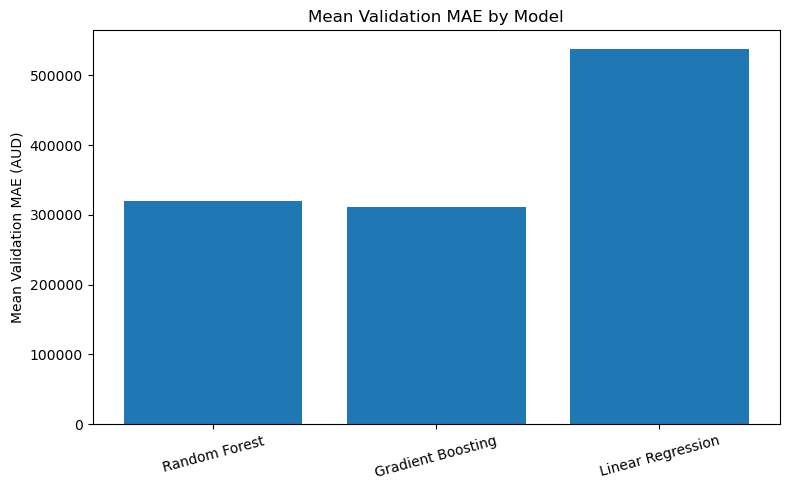

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Mean Validation MAE"])
plt.ylabel("Mean Validation MAE (AUD)")
plt.title("Mean Validation MAE by Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


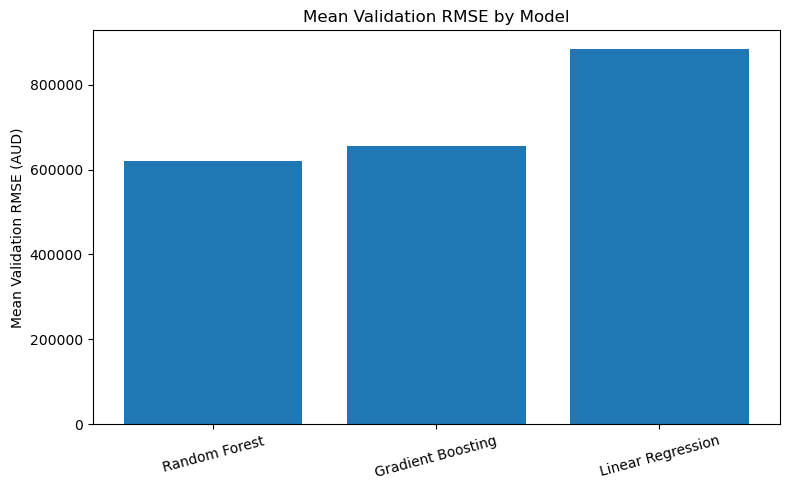

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Mean Validation RMSE"])
plt.ylabel("Mean Validation RMSE (AUD)")
plt.title("Mean Validation RMSE by Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


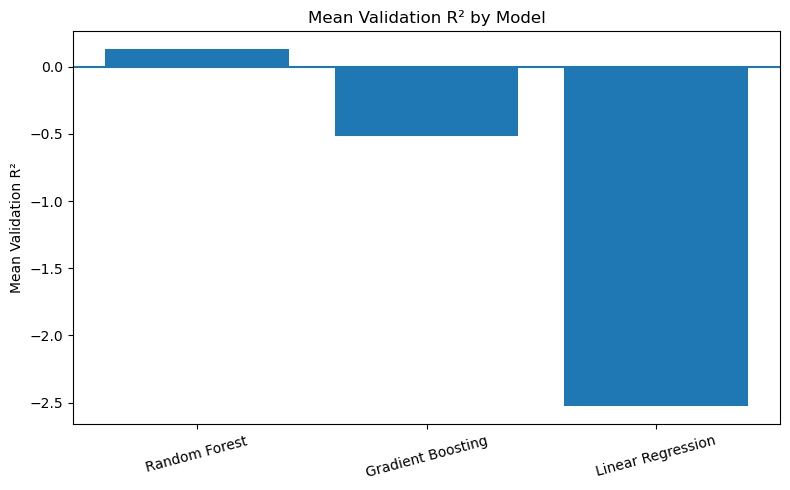

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Mean Validation R²"])
plt.ylabel("Mean Validation R²")
plt.title("Mean Validation R² by Model")
plt.axhline(0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 13. Compare training and validation

- Check whether training errors are much smaller than validation errors.
- Use the gaps together with the fold results to assess overfitting.


In [15]:
fit_check = summary[
    [
        "Model",
        "Mean Train MAE",
        "Mean Validation MAE",
        "Mean Train RMSE",
        "Mean Validation RMSE",
        "Mean Train R²",
        "Mean Validation R²"
    ]
].copy()

fit_check["RMSE Gap"] = (
    fit_check["Mean Validation RMSE"] -
    fit_check["Mean Train RMSE"]
)

fit_check["R² Gap"] = (
    fit_check["Mean Train R²"] -
    fit_check["Mean Validation R²"]
)

display(fit_check.round(3))


,Model,Mean Train MAE,Mean Validation MAE,Mean Train RMSE,Mean Validation RMSE,Mean Train R²,Mean Validation R²,RMSE Gap,R² Gap
0,Linear Regression,352592.729,537421.264,561219.213,883702.397,0.710,-2.527,322483.184,3.237
1,Random Forest,187275.592,320209.030,469791.056,620717.165,0.801,0.129,150926.109,0.672
2,Gradient Boosting,133337.104,311444.370,233674.646,655441.447,0.942,-0.514,421766.801,1.456


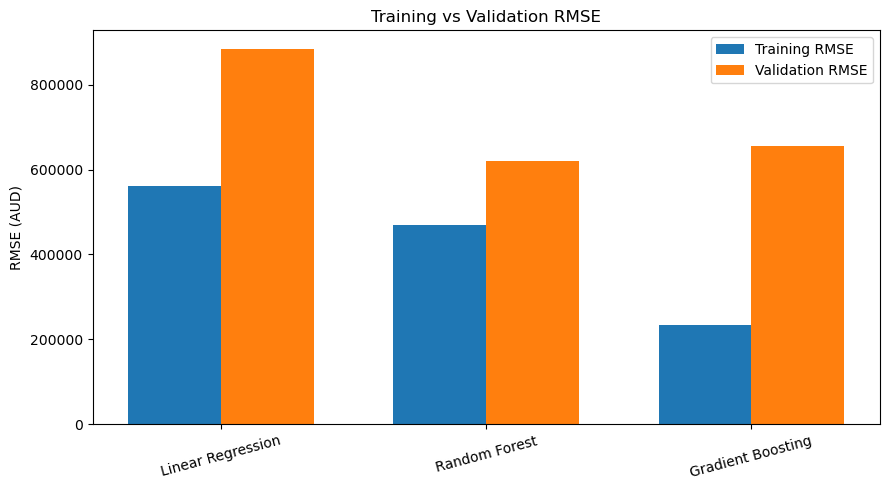

In [16]:
x = np.arange(len(fit_check))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, fit_check["Mean Train RMSE"], width, label="Training RMSE")
plt.bar(x + width/2, fit_check["Mean Validation RMSE"], width, label="Validation RMSE")

plt.xticks(x, fit_check["Model"], rotation=15)
plt.ylabel("RMSE (AUD)")
plt.title("Training vs Validation RMSE")
plt.legend()
plt.tight_layout()
plt.show()



## 14. Plot actual and predicted prices

- Each property is predicted by a model that did not train on that property.
- Points near the diagonal line have smaller errors.


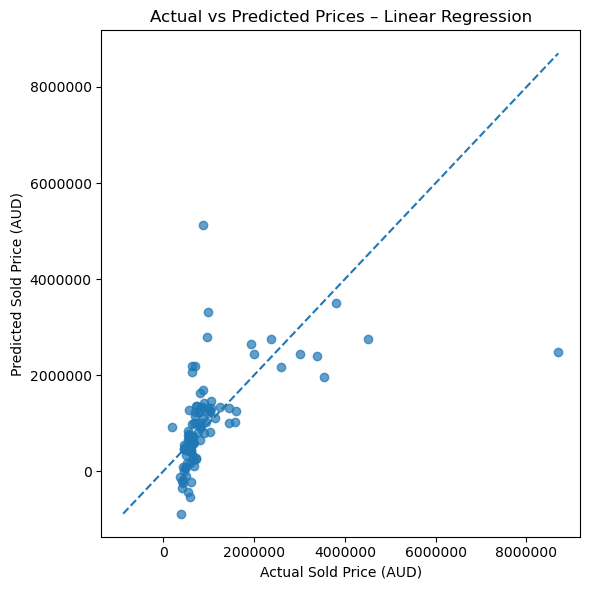

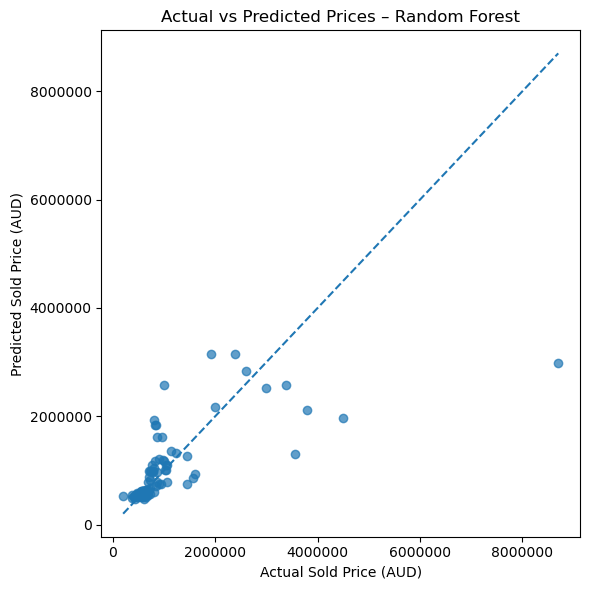

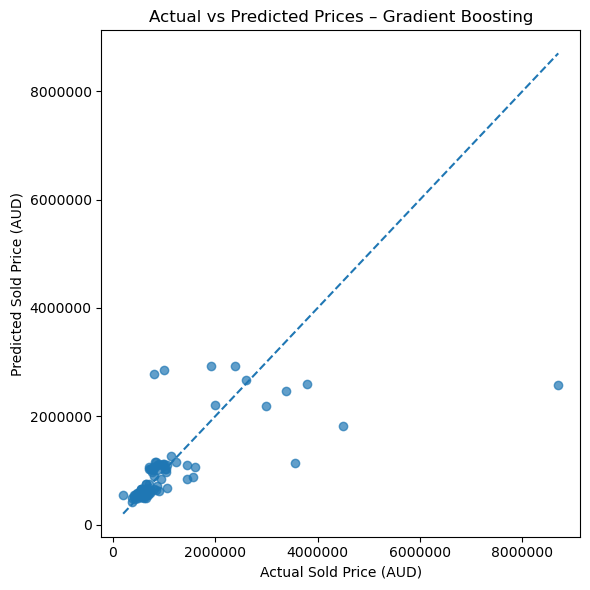

In [17]:
from sklearn.model_selection import cross_val_predict

for name, pipeline in pipelines.items():
    predictions = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv
    )

    plt.figure(figsize=(6, 6))
    plt.scatter(y, predictions, alpha=0.7)

    lower = min(y.min(), predictions.min())
    upper = max(y.max(), predictions.max())
    plt.plot([lower, upper], [lower, upper], linestyle="--")

    plt.xlabel("Actual Sold Price (AUD)")
    plt.ylabel("Predicted Sold Price (AUD)")
    plt.title(f"Actual vs Predicted Prices – {name}")
    plt.ticklabel_format(style="plain", axis="both")
    plt.tight_layout()
    plt.show()


## 15. Review the results

- Summarise the model behaviour using the results above.
- Revisit the initial expectation and select the model for Part 4.


In [18]:
# Read the conclusions from the current results instead of typing fixed scores.
best_model_name = comparison.iloc[0]["Model"]
lowest_mae = summary.loc[summary["Mean Validation MAE"].idxmin(), "Model"]
print(f"Lowest validation MAE: {lowest_mae}")
print(f"Recommended model by validation RMSE: {best_model_name}")
print("Initial Random Forest expectation supported:", best_model_name == "Random Forest")
for _, row in fit_check.iterrows():
    name = row["Model"]
    fold_r2 = all_results[name]["Validation R²"]
    print(f"\n{name}: training R² = {row['Mean Train R²']:.3f}, validation R² = {row['Mean Validation R²']:.3f}")
    print(f"RMSE gap = ${row['RMSE Gap']:,.0f}; fold R² range = {fold_r2.min():.3f} to {fold_r2.max():.3f}")
size_difference = size_check.iloc[1]["Mean Validation RMSE"] - size_check.iloc[0]["Mean Validation RMSE"]
print(f"\nAdding size fields changes validation RMSE by ${size_difference:,.0f}.")
print("Lower is better. The size-feature check is exploratory and separate from the three-model ranking.")


Lowest validation MAE: Gradient Boosting
Recommended model by validation RMSE: Random Forest
Initial Random Forest expectation supported: True

Linear Regression: training R² = 0.710, validation R² = -2.527
RMSE gap = $322,483; fold R² range = -12.710 to 0.384

Random Forest: training R² = 0.801, validation R² = 0.129
RMSE gap = $150,926; fold R² range = -1.247 to 0.929

Gradient Boosting: training R² = 0.942, validation R² = -0.514
RMSE gap = $421,767; fold R² range = -4.800 to 0.828

Adding size fields changes validation RMSE by $6,133.
Lower is better. The size-feature check is exploratory and separate from the three-model ranking.


### Short findings

- Gradient Boosting has the lowest MAE, while Random Forest has the lowest RMSE and highest mean validation R².
- Random Forest remains the recommended model, which supports the initial expectation.
- Gradient Boosting fits the training data closely but has a much weaker validation result. This suggests overfitting.
- Linear Regression also has a large training-to-validation gap. Its weak validation result alone does not prove underfitting.
- Dropping a reference category did not resolve the poor Linear Regression result. The cause cannot be assigned to one preprocessing issue.
- The size-feature experiment has a higher validation RMSE, so the simpler version without size fields is retained.
- All models vary between folds. The recommendation is provisional because the same folds were used to compare and select models.


## 16. Save the model comparison

- Save the results for the report.


In [19]:
summary.to_csv("Part_3_Model_Evaluation_Results.csv", index=False)

print("Saved: Part_3_Model_Evaluation_Results.csv")
display(summary.round(3))


Saved: Part_3_Model_Evaluation_Results.csv


,Model,Mean Train MAE,Mean Validation MAE,Mean Train RMSE,Mean Validation RMSE,Mean Train R²,Mean Validation R²,Validation MAE Std,Validation RMSE Std,Validation R² Std
0,Linear Regression,352592.729,537421.264,561219.213,883702.397,0.710,-2.527,137376.173,447560.987,5.701
1,Random Forest,187275.592,320209.030,469791.056,620717.165,0.801,0.129,204934.672,504694.340,0.823
2,Gradient Boosting,133337.104,311444.370,233674.646,655441.447,0.942,-0.514,188783.324,519746.246,2.402


# Part 4 – Investigating Prediction Failures

- Use the model with the lowest mean validation RMSE.
- Find the five largest absolute out-of-fold errors.
- Check the property details and possible reasons for each error.


## 17. Calculate prediction errors

- Error = actual price − predicted price.
- A positive error means the model underpredicted the price.


In [20]:
# Select the model with the lowest mean validation RMSE from Part 3.
best_model_name = summary.loc[
    summary["Mean Validation RMSE"].idxmin(),
    "Model"
]

selected_pipeline = pipelines[best_model_name]

print("Selected model:", best_model_name)

# Create out-of-fold predictions using 5-fold cross-validation.
selected_predictions = cross_val_predict(
    selected_pipeline,
    X,
    y,
    cv=cv
)

# Use the cleaned modelling dataframe.
error_analysis = model_df.copy()

# Add the actual sold price directly from y.
error_analysis["Actual Price (AUD)"] = y.values

# Add the predicted price.
error_analysis["Predicted Price (AUD)"] = selected_predictions

# Calculate the prediction error.
error_analysis["Prediction Error (AUD)"] = (
    error_analysis["Actual Price (AUD)"] -
    error_analysis["Predicted Price (AUD)"]
)

# Calculate the absolute prediction error.
error_analysis["Absolute Error (AUD)"] = (
    error_analysis["Prediction Error (AUD)"].abs()
)

# Find the five properties with the largest errors.
top_5_errors = error_analysis.nlargest(
    5,
    "Absolute Error (AUD)"
).copy()

print("Five properties with the largest prediction errors:")
display(top_5_errors)

Selected model: Random Forest
Five properties with the largest prediction errors:


,ID,Address,Suburb,State,Postcode,Year Built,Sold Price (AUD),Sold Date,Property Type,Bedrooms,Bathrooms,Has Parking,Car Spaces,Land Size (m²),Building Size (m²),Approx. Distance to Sydney CBD (km),Has Pool,Listing Source URL,Results Page URL,Sold Month,Total Rooms,Actual Price (AUD),Predicted Price (AUD),Prediction Error (AUD),Absolute Error (AUD)
13,14,5 Botanic Road,Mosman,NSW,2088,NaN,8700000,2026-07-22,House,4.0,3,1.0,2.0,NaN,NaN,8,1,https://www.realestate.com.au/sold/property-ho...,"https://www.realestate.com.au/sold/in-mosman,+...",7,7.0,8700000,2.990979e+06,5.709021e+06,5.709021e+06
4,5,G05/15-25 Myahgah Road,Mosman,NSW,2088,NaN,4500000,2026-08-31,Apartment,2.0,2,1.0,2.0,NaN,NaN,8,0,https://www.realestate.com.au/sold/property-ap...,"https://www.realestate.com.au/sold/in-mosman,+...",8,4.0,4500000,1.966202e+06,2.533798e+06,2.533798e+06
25,26,105 Holt Avenue,Mosman,NSW,2088,NaN,3550000,2026-06-05,House,4.0,3,NaN,NaN,NaN,NaN,8,0,https://www.realestate.com.au/sold/property-ho...,"https://www.realestate.com.au/sold/in-mosman,+...",6,7.0,3550000,1.310693e+06,2.239307e+06,2.239307e+06
12,13,142/15 Hale Road,Mosman,NSW,2088,NaN,3800000,2026-07-24,Retirement living,3.0,2,1.0,2.0,NaN,NaN,8,1,https://www.realestate.com.au/sold/property-re...,"https://www.realestate.com.au/sold/in-mosman,+...",7,5.0,3800000,2.108346e+06,1.691654e+06,1.691654e+06
97,98,178A Derby Street,Penrith,NSW,2750,NaN,990000,2026-08-07,House,3.0,3,1.0,2.0,299.0,NaN,50,0,https://www.realestate.com.au/sold/property-ho...,"https://www.realestate.com.au/sold/in-penrith,...",8,6.0,990000,2.571101e+06,-1.581101e+06,1.581101e+06


## 18. Inspect the five largest errors

- Show actual prices, predicted prices and property features.
- Keep missing values visible because they are part of the investigation.


In [21]:
columns_to_show = [
    "Address",
    "Suburb",
    "Property Type",
    "Bedrooms",
    "Bathrooms",
    "Has Parking",
    "Car Spaces",
    "Land Size (m²)",
    "Building Size (m²)",
    "Year Built",
    "Actual Price (AUD)",
    "Predicted Price (AUD)",
    "Prediction Error (AUD)",
    "Absolute Error (AUD)"
]

display(
    top_5_errors[
        [col for col in columns_to_show if col in top_5_errors.columns]
    ].round(2)
)


,Address,Suburb,Property Type,Bedrooms,Bathrooms,Has Parking,Car Spaces,Land Size (m²),Building Size (m²),Year Built,Actual Price (AUD),Predicted Price (AUD),Prediction Error (AUD),Absolute Error (AUD)
13,5 Botanic Road,Mosman,House,4.0,3,1.0,2.0,NaN,NaN,NaN,8700000,2990979.36,5709020.64,5709020.64
4,G05/15-25 Myahgah Road,Mosman,Apartment,2.0,2,1.0,2.0,NaN,NaN,NaN,4500000,1966202.35,2533797.65,2533797.65
25,105 Holt Avenue,Mosman,House,4.0,3,NaN,NaN,NaN,NaN,NaN,3550000,1310693.27,2239306.73,2239306.73
12,142/15 Hale Road,Mosman,Retirement living,3.0,2,1.0,2.0,NaN,NaN,NaN,3800000,2108346.04,1691653.96,1691653.96
97,178A Derby Street,Penrith,House,3.0,3,1.0,2.0,299.0,NaN,NaN,990000,2571100.92,-1581100.92,1581100.92


## 19. Plot the five largest errors


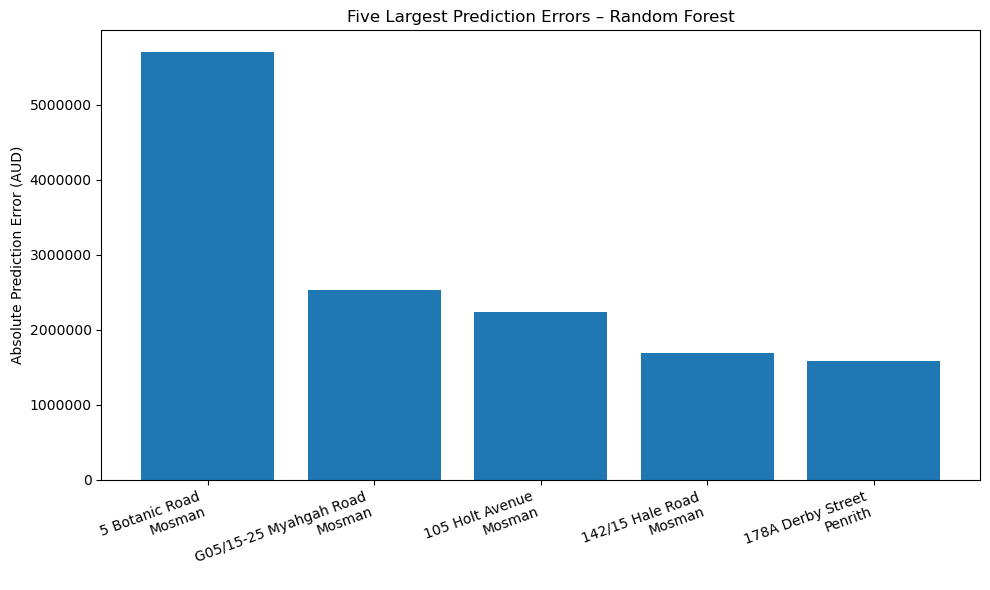

In [22]:
labels = (
    top_5_errors["Address"].astype(str)
    + "\n"
    + top_5_errors["Suburb"].astype(str)
)

plt.figure(figsize=(10, 6))
plt.bar(labels, top_5_errors["Absolute Error (AUD)"])
plt.ylabel("Absolute Prediction Error (AUD)")
plt.title(f"Five Largest Prediction Errors – {best_model_name}")
plt.xticks(rotation=20, ha="right")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


## 20. Save the five properties


In [23]:
top_5_errors[columns_to_show].to_csv(
    "Part_4_Top_5_Prediction_Errors.csv",
    index=False
)

print("Saved: Part_4_Top_5_Prediction_Errors.csv")


Saved: Part_4_Top_5_Prediction_Errors.csv


## 21. Review each property

- Compare the size of the error with the available property details.
- The possible explanations below are not confirmed listing facts.
- Missing information and unusual properties may explain part of the error.


In [24]:
# These notes use the recorded features of each property.
# Possible explanations are kept cautious because the listing text was not collected.
case_notes = {
    "5 Botanic Road": (
        "This four-bedroom, three-bathroom Mosman house sold for $8.70 million, "
        "which is much higher than the model prediction. It also has a pool and two car spaces, "
        "but land size, building size and year built are missing. These missing size and quality "
        "details make it difficult to represent a premium house accurately."
    ),
    "G05/15-25 Myahgah Road": (
        "This two-bedroom Mosman apartment sold for $4.50 million even though its room counts are "
        "similar to many lower-priced apartments. It has two bathrooms and two car spaces, but its "
        "building size and year built are missing. Features such as floor level, view, condition or "
        "building quality were unavailable and may help explain the high price."
    ),
    "105 Holt Avenue": (
        "This four-bedroom, three-bathroom Mosman house was underpredicted by more than $2 million. "
        "Parking, land size, building size and year built are all missing. The model therefore relies "
        "mostly on suburb, property type and room counts, which cannot describe the full value of this house."
    ),
    "142/15 Hale Road": (
        "This three-bedroom retirement property in Mosman sold for $3.80 million. Retirement living is "
        "a less common property type in this dataset, so the model has fewer similar examples to learn from. "
        "The property also has a pool and two car spaces, while its size and age are missing."
    ),
    "178A Derby Street": (
        "This Penrith house was overpredicted even though its actual price was $990,000. It has three "
        "bedrooms, three bathrooms, two car spaces and a recorded land size of 299 m². The high room counts "
        "may have pushed the prediction upward, while building size, age, condition and sale circumstances "
        "were unavailable."
    ),
}

for _, row in top_5_errors.iterrows():
    actual = row["Actual Price (AUD)"]
    predicted = row["Predicted Price (AUD)"]
    error = row["Absolute Error (AUD)"]
    direction = "underpredicted" if actual > predicted else "overpredicted"

    print(f"\n{row['Address']} — {row['Suburb']}")
    print(f"- Actual price: ${actual:,.0f}")
    print(f"- Predicted price: ${predicted:,.0f}")
    print(f"- The model {direction} the price by ${error:,.0f}.")
    print(f"- Investigation: {case_notes[row['Address']]}")



5 Botanic Road — Mosman
- Actual price: $8,700,000
- Predicted price: $2,990,979
- The model underpredicted the price by $5,709,021.
- Investigation: This four-bedroom, three-bathroom Mosman house sold for $8.70 million, which is much higher than the model prediction. It also has a pool and two car spaces, but land size, building size and year built are missing. These missing size and quality details make it difficult to represent a premium house accurately.

G05/15-25 Myahgah Road — Mosman
- Actual price: $4,500,000
- Predicted price: $1,966,202
- The model underpredicted the price by $2,533,798.
- Investigation: This two-bedroom Mosman apartment sold for $4.50 million even though its room counts are similar to many lower-priced apartments. It has two bathrooms and two car spaces, but its building size and year built are missing. Features such as floor level, view, condition or building quality were unavailable and may help explain the high price.

105 Holt Avenue — Mosman
- Actual p

## 22. Limitations and cautious use

- Only 102 properties are available from three suburbs. They do not represent all of Sydney.
- A few expensive properties have a large effect on the errors.
- Land size, building size and year built are often missing.
- Property condition, renovations, views, floor level and detailed agent descriptions were not included.
- Luxury homes and unusual property types can be harder to predict when there are few similar examples.
- Prices should be treated cautiously for other suburbs or properties outside the observed price range.
- The five cases help explain failures, but they do not prove that a property type is always harder to model.
- A larger dataset and an independent test set would give a stronger check of performance.


## 23. Part 4 summary

- Random Forest gives the lowest mean validation RMSE in this run.
- Gradient Boosting gives the lowest MAE but is less reliable for the larger errors.
- Increasing model complexity does not always improve validation results on this small dataset.
- The largest errors show that luxury homes and less common properties need more detailed information.
- These predictions are a starting point, not a reliable valuation for every property.

# Part 5 – Final Deployment and Reflection

- Save the selected model with the preprocessing steps.
- Create a simple Streamlit application.
- Allow one property to be entered manually or several properties to be uploaded in a CSV file.
- Explain how to run the application and reflect on the complete project.


## 24. Train and save the final model

Random Forest is used because it achieved the lowest mean validation RMSE and the highest mean validation R². The full pipeline is fitted on all 102 properties after model selection. This keeps the same imputation and encoding steps used during evaluation.


In [25]:
from sklearn.base import clone
import joblib

# Copy the selected pipeline so the evaluation objects stay unchanged.
deployment_model = clone(pipelines[best_model_name])

# Fit the final version on all available properties.
deployment_model.fit(X, y)

# Save the values used to build the input controls in the web application.
category_values = {
    column: sorted(X[column].dropna().astype(str).unique().tolist())
    for column in categorical_features
}

numeric_defaults = {
    column: float(pd.to_numeric(X[column], errors="coerce").median())
    for column in numerical_features
}

deployment_bundle = {
    "model": deployment_model,
    "model_name": best_model_name,
    "feature_columns": X.columns.tolist(),
    "category_values": category_values,
    "numeric_defaults": numeric_defaults,
    "validation_rmse": float(
        summary.loc[
            summary["Model"] == best_model_name,
            "Mean Validation RMSE"
        ].iloc[0]
    )
}

joblib.dump(deployment_bundle, "syd_house_price_model.joblib")

print("Saved model: syd_house_price_model.joblib")
print("Deployed model:", best_model_name)
print("Model inputs:", X.columns.tolist())


Saved model: syd_house_price_model.joblib
Deployed model: Random Forest
Model inputs: ['Suburb', 'State', 'Property Type', 'Bedrooms', 'Bathrooms', 'Has Parking', 'Car Spaces', 'Approx. Distance to Sydney CBD (km)', 'Has Pool', 'Sold Month', 'Total Rooms']


## 25. Create the Streamlit application

The application uses the saved pipeline, so the user inputs receive the same preprocessing as the training data. The manual page predicts one property. The upload page predicts all valid rows in a CSV file.


In [26]:
from pathlib import Path

# The application code is stored as text and saved as app.py.
app_code = r'''import joblib
from pathlib import Path

import pandas as pd
import streamlit as st


st.set_page_config(page_title="Sydney House Price Predictor", page_icon="🏠")

MODEL_PATH = Path(__file__).with_name("syd_house_price_model.joblib")
bundle = joblib.load(MODEL_PATH)
model = bundle["model"]
feature_columns = bundle["feature_columns"]
category_values = bundle["category_values"]
numeric_defaults = bundle["numeric_defaults"]


def prepare_features(data):
    """Create the same features used when the model was trained."""
    prepared = data.copy()

    # Sold Month can be supplied directly or calculated from Sold Date.
    if "Sold Month" not in prepared.columns and "Sold Date" in prepared.columns:
        sold_dates = pd.to_datetime(prepared["Sold Date"], errors="coerce")
        prepared["Sold Month"] = sold_dates.dt.month

    # Total Rooms is calculated from the two room-count columns.
    if "Total Rooms" not in prepared.columns:
        if {"Bedrooms", "Bathrooms"}.issubset(prepared.columns):
            prepared["Total Rooms"] = (
                pd.to_numeric(prepared["Bedrooms"], errors="coerce").fillna(0)
                + pd.to_numeric(prepared["Bathrooms"], errors="coerce").fillna(0)
            )

    missing = [column for column in feature_columns if column not in prepared.columns]
    if missing:
        raise ValueError("Missing columns: " + ", ".join(missing))

    return prepared[feature_columns]


st.title("Sydney House Price Predictor")
st.write(
    "This application gives an estimated sale price using the Random Forest model "
    "developed from the collected Mosman, Parramatta and Penrith data."
)

manual_tab, upload_tab = st.tabs(["Enter one property", "Upload CSV"])

with manual_tab:
    with st.form("property_form"):
        suburb = st.selectbox("Suburb", category_values["Suburb"])
        property_type = st.selectbox("Property type", category_values["Property Type"])
        state = st.selectbox("State", category_values["State"])

        bedrooms = st.number_input("Bedrooms", min_value=0.0, max_value=10.0, value=3.0, step=1.0)
        bathrooms = st.number_input("Bathrooms", min_value=0.0, max_value=10.0, value=2.0, step=1.0)
        car_spaces = st.number_input("Car spaces", min_value=0.0, max_value=10.0, value=1.0, step=1.0)
        has_parking = st.selectbox("Has parking", ["Yes", "No"])
        has_pool = st.selectbox("Has pool", ["No", "Yes"])
        distance = st.number_input(
            "Approximate distance to Sydney CBD (km)",
            min_value=0.0,
            max_value=100.0,
            value=float(numeric_defaults["Approx. Distance to Sydney CBD (km)"]),
            step=1.0
        )
        sold_month = st.slider("Sold month", 1, 12, 9)
        submitted = st.form_submit_button("Predict sale price")

    if submitted:
        property_data = pd.DataFrame([{
            "Suburb": suburb,
            "State": state,
            "Property Type": property_type,
            "Bedrooms": bedrooms,
            "Bathrooms": bathrooms,
            "Has Parking": 1 if has_parking == "Yes" else 0,
            "Car Spaces": car_spaces,
            "Approx. Distance to Sydney CBD (km)": distance,
            "Has Pool": 1 if has_pool == "Yes" else 0,
            "Sold Month": sold_month,
            "Total Rooms": bedrooms + bathrooms,
        }])

        prediction = model.predict(prepare_features(property_data))[0]
        st.metric("Estimated sale price", f"${prediction:,.0f}")
        st.caption(
            "This is a model estimate based on a small dataset. It should not be treated "
            "as a professional property valuation."
        )

with upload_tab:
    st.write("Upload a CSV file containing the model input columns shown below.")
    st.code(", ".join(feature_columns))
    uploaded_file = st.file_uploader("Choose a CSV file", type="csv")

    if uploaded_file is not None:
        try:
            uploaded_data = pd.read_csv(uploaded_file)
            uploaded_features = prepare_features(uploaded_data)
            results = uploaded_data.copy()
            results["Predicted Sale Price (AUD)"] = model.predict(uploaded_features)

            st.success(f"Predictions created for {len(results)} properties.")
            st.dataframe(results, use_container_width=True)
            st.download_button(
                "Download predictions",
                results.to_csv(index=False).encode("utf-8"),
                file_name="property_price_predictions.csv",
                mime="text/csv"
            )
        except Exception as error:
            st.error(f"The predictions could not be created. {error}")

st.divider()
st.caption(
    f"Model: {bundle['model_name']} | Mean cross-validation RMSE: "
    f"${bundle['validation_rmse']:,.0f}"
)
'''

Path("app.py").write_text(app_code, encoding="utf-8")

# These packages are enough to run the saved model and Streamlit interface.
requirements = """streamlit>=1.38,<2
pandas>=2.2,<3
scikit-learn==1.8.0
joblib>=1.4,<2
"""
Path("requirements.txt").write_text(requirements, encoding="utf-8")

print("Saved application: app.py")
print("Saved package list: requirements.txt")


Saved application: app.py
Saved package list: requirements.txt


## 26. Create a sample upload file and check the deployment

The sample CSV shows the required upload format. A test prediction also checks that the saved model can be loaded and used without the training notebook.


In [27]:
# Create one example row for the CSV upload page.
sample_upload = pd.DataFrame([{
    "Suburb": "Parramatta",
    "State": "NSW",
    "Property Type": "Apartment",
    "Bedrooms": 2,
    "Bathrooms": 1,
    "Has Parking": 1,
    "Car Spaces": 1,
    "Approx. Distance to Sydney CBD (km)": 24,
    "Has Pool": 0,
    "Sold Month": 9,
    "Total Rooms": 3,
}])
sample_upload.to_csv("sample_property_upload.csv", index=False)

# Load the saved file again to check that deployment is independent of training.
saved_bundle = joblib.load("syd_house_price_model.joblib")
test_prediction = saved_bundle["model"].predict(
    sample_upload[saved_bundle["feature_columns"]]
)[0]

print("Deployment check completed.")
print(f"Sample predicted price: ${test_prediction:,.0f}")
print("Created: sample_property_upload.csv")


Deployment check completed.
Sample predicted price: $552,496
Created: sample_property_upload.csv


## 27. Run and use the application

Open Terminal in the folder containing the notebook outputs and run:

```bash
pip install -r requirements.txt
streamlit run app.py
```

The browser opens the application automatically.

- **Enter one property:** choose the property details and select **Predict sale price**.
- **Upload CSV:** upload a file in the same format as `sample_property_upload.csv` and download the results.
- For the report, one screenshot can show the completed input form and predicted price. A second screenshot can show the CSV upload results.


## 28. Deployment limitations

- The application is based on only 102 properties from Mosman, Parramatta and Penrith.
- Predictions outside these suburbs or outside the observed price range are less reliable.
- Important information such as property condition, exact location, views and renovations is unavailable.
- Land size, building size and year built were excluded from the deployed model because they were mostly missing and did not improve validation RMSE in the test.
- The displayed result is an estimate. It is not a professional property valuation.


## 29. Reflection

This project helped me understand the complete machine learning workflow. The first challenge was collecting consistent property data from different listing pages. Some useful fields were missing for most properties, especially land size, building size and year built. This showed that having more columns does not always mean that the data is useful.

During preprocessing, I learned that each feature must be handled according to its meaning. Postcode was removed because it is a location label and mostly repeated the suburb information. Categorical values were one-hot encoded, while missing numerical values were filled inside each training fold. I also tested the two size features with missing-value indicators before deciding to leave them out of the final model.

The model results showed the trade-off between complexity and generalisation. Gradient Boosting fitted the training data very closely but performed less consistently on validation data. Random Forest gave the best validation RMSE and R², although its R² was still low. The five largest errors also showed that expensive and unusual properties were difficult to predict with the available features.

Deployment introduced another practical trade-off. A simpler model with stable inputs is easier to use in a web application, but some predictive information may be lost. The application is useful for demonstrating the workflow, but its prediction should be treated carefully because the dataset is small and covers only three suburbs.

The data may also contain bias. Mosman has many high-priced properties, while Parramatta and Penrith have different price ranges and property mixes. A model trained on this sample may give less reliable results for underrepresented property types or locations. If more time and data were available, the project could include more suburbs, recent sales, property condition, floor area, views, renovations and text from the listing description. Hyperparameter tuning and a separate final test set would also provide a stronger evaluation.
